# 02 — Đo thời gian trên GPU cho đúng

Mọi con số tốc độ trong dự án — 1,92×, 1,17×, "chậm hơn 5%" — đều đứng trên một phép đo
thời gian. Trên GPU laptop, phép đo đó có bốn cái bẫy: GPU chạy **bất đồng bộ**, lần chạy
đầu **chậm bất thường**, xung nhịp **dao động theo nhiệt độ**, và máy **trôi dần** trong
một phiên đo dài. Notebook này đo từng cái bẫy trên chính máy này, rồi dẫn ra sáu quy tắc
đo của dự án và định luật Amdahl — công cụ cho biết tối ưu phần nào thì đáng.

Nền tảng cần có: notebook 00 (trung vị, khoảng tin cậy, bootstrap).

| Mục | Nội dung |
|---|---|
| 1 | GPU chạy bất đồng bộ |
| 2 | Lần chạy đầu và làm nóng |
| 3 | Nhiễu: phân phối của độ trễ, trung vị và IQR, hệ số biến thiên |
| 4 | Xung nhịp và nhiệt độ |
| 5 | Trôi theo thời gian, và vì sao phải xen kẽ các cấu hình |
| 6 | Khi nào được nói "nhanh hơn" |
| 7 | Profiler: thời gian nằm ở phép tính nào |
| 8 | Định luật Amdahl |

In [1]:
import json, math, statistics, sys, time
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
from bench.latency_probe import GpuSampler, summarize

RESULTS = Path("../results")
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (7, 3.2), "figure.dpi": 110})
dev = "cuda"

def load(name):
    return json.loads((RESULTS / name).read_text())

## 1. GPU chạy bất đồng bộ

Khi Python gọi một phép tính trên GPU, PyTorch **không chờ** GPU tính xong. Nó chỉ xếp
lệnh vào một **hàng đợi** (CUDA stream) rồi trả về ngay; GPU lấy lệnh ra chạy sau. Nhờ vậy
CPU có thể chuẩn bị lệnh tiếp theo trong lúc GPU đang bận.

Hệ quả cho việc đo: bấm giờ bằng đồng hồ của CPU quanh một lệnh GPU sẽ đo **thời gian xếp
lệnh**, không phải thời gian chạy. Ba cách đo cùng một phép nhân ma trận:

In [2]:
N = 4096
a = torch.randn(N, N, device=dev, dtype=torch.bfloat16)
b = torch.randn(N, N, device=dev, dtype=torch.bfloat16)
for _ in range(5):
    a @ b                                                # warm up (section 2)
torch.cuda.synchronize()

t = time.perf_counter(); c = a @ b
t_nosync = (time.perf_counter() - t) * 1e3               # CPU clock, no wait

torch.cuda.synchronize()
t = time.perf_counter(); c = a @ b; torch.cuda.synchronize()
t_sync = (time.perf_counter() - t) * 1e3                 # CPU clock, wait for the GPU

s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
s.record(); c = a @ b; e.record(); torch.cuda.synchronize()
t_event = s.elapsed_time(e)                              # timestamps recorded on the GPU itself

print(f"CPU clock, no synchronize : {t_nosync:7.3f} ms   <- only the time to queue the work")
print(f"CPU clock + synchronize   : {t_sync:7.3f} ms")
print(f"CUDA events               : {t_event:7.3f} ms")

CPU clock, no synchronize :   0.244 ms   <- only the time to queue the work
CPU clock + synchronize   :   5.801 ms
CUDA events               :   4.124 ms


Cách thứ nhất báo con số nhỏ hơn hàng chục lần — nó chỉ đo lúc CPU **xếp lệnh**. Hai cách
còn lại đúng:
- `torch.cuda.synchronize()` bắt CPU chờ đến khi hàng đợi trống.
- **CUDA event** là một "mốc" được chèn vào chính hàng đợi của GPU; GPU ghi thời điểm khi
  chạy tới mốc đó. Khoảng cách giữa hai mốc là thời gian GPU thực sự chạy, không lẫn độ
  trễ của CPU. Đây là cách `bench/latency_probe.py` và `bench/harness.py` dùng.

## 2. Lần chạy đầu và làm nóng

Lần đầu một phép tính chạy, hệ thống phải làm những việc chỉ làm một lần: cấp phát bộ nhớ,
nạp thư viện kernel, và để cuBLAS chọn thuật toán nhân ma trận hợp với kích thước đó. Đo
một phép nhân ma trận **kích thước mới** lần đầu và các lần sau:

In [3]:
x = torch.randn(3000, 5000, device=dev, dtype=torch.float32)     # a shape not used before
y = torch.randn(5000, 2000, device=dev, dtype=torch.float32)
times = []
for i in range(6):
    s, e = torch.cuda.Event(True), torch.cuda.Event(True)
    s.record(); x @ y; e.record(); torch.cuda.synchronize()
    times.append(s.elapsed_time(e))
print("call 1..6 (ms):", [round(t, 2) for t in times])
del a, b, c, x, y; torch.cuda.empty_cache()

call 1..6 (ms): [59.64, 11.36, 13.03, 14.52, 16.17, 16.17]


Lần đầu chậm hơn hẳn các lần sau. Vì vậy mọi phép đo trong dự án đều chạy **làm nóng**
(warm-up) vài lần trước và bỏ kết quả của chúng.

Với cả mô hình, hiệu ứng này còn rõ hơn: lần `generate` đầu tiên sau khi nạp mô hình phải
khởi tạo mọi kernel của hàng trăm lớp.

In [4]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from bench.harness import load_samples, PROMPT

MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()
sample = load_samples(1, seed=0)[0]
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
inputs = proc(text=proc.apply_chat_template(msg, add_generation_prompt=True),
              images=[sample["image"]], return_tensors="pt").to(dev)

def gen():
    return model.generate(**inputs, max_new_tokens=32, do_sample=False)

def timed(fn):
    s, e = torch.cuda.Event(True), torch.cuda.Event(True)
    torch.cuda.synchronize(); s.record(); fn(); e.record(); torch.cuda.synchronize()
    return s.elapsed_time(e)

with torch.no_grad():
    first = [timed(gen) for _ in range(3)]
print("first three generate calls after loading (ms):", [round(t) for t in first])

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

first three generate calls after loading (ms): [2049, 951, 979]


## 3. Nhiễu: phân phối của độ trễ

Chạy **cùng một** câu hỏi 40 lần liên tiếp, đồng thời ghi xung nhịp và nhiệt độ GPU mỗi
0,25 giây bằng `GpuSampler` của dự án (nó gọi `nvidia-smi` trong một luồng riêng).

median 975 ms | mean 965 ms | min 894 | max 1020 | p95 1019
IQR = 66 ms (6.8% of median) | CV = 4.1%


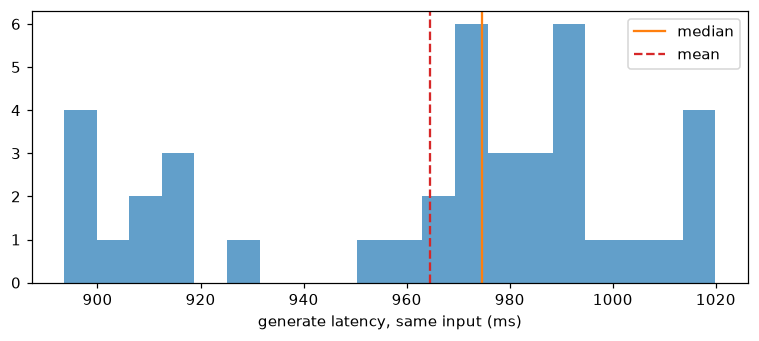

In [5]:
sampler = GpuSampler(period=0.25); sampler.start()
lat, clk_at = [], []
with torch.no_grad():
    for _ in range(40):
        lat.append(timed(gen))
        clk_at.append(sampler.rows[-1]["clock_mhz"] if sampler.rows else float("nan"))
sampler.stop()
lat = np.array(lat)
st = summarize(list(lat))
print(f"median {st['median']:.0f} ms | mean {st['mean']:.0f} ms | min {st['min']:.0f} | max {st['max']:.0f} | p95 {st['p95']:.0f}")
print(f"IQR = {st['p75'] - st['p25']:.0f} ms ({st['iqr_pct']:.1f}% of median) | CV = {st['cv_pct']:.1f}%")
plt.hist(lat, bins=20, alpha=0.7)
plt.axvline(st["median"], c="C1", label="median"); plt.axvline(st["mean"], c="C3", ls="--", label="mean")
plt.xlabel("generate latency, same input (ms)"); plt.legend(); plt.tight_layout(); plt.show()

Ba đại lượng mô tả độ phân tán dùng trong dự án:

- **Phân vị** $q$: giá trị mà $q\%$ số quan sát nằm dưới nó. Trung vị là phân vị 50; **p95**
  là phân vị 95 — "95% số lần nhanh hơn mức này", thước đo quen thuộc cho độ trễ dịch vụ.
- **Khoảng tứ phân vị** (IQR): khoảng cách giữa phân vị 75 và phân vị 25 — độ rộng của
  "nửa giữa" dữ liệu. Dự án báo IQR dưới dạng phần trăm của trung vị.
- **Hệ số biến thiên** (CV): độ lệch chuẩn chia cho trung bình, tính bằng phần trăm.

$$\mathrm{IQR} = Q_{75} - Q_{25}, \qquad \mathrm{CV} = \frac{\sigma}{\mu} \times 100\%$$

**Ký hiệu mới**
- $Q_{25}, Q_{75}$: phân vị 25 và 75 · $\sigma, \mu$: độ lệch chuẩn và trung bình của các lần đo

**Vì sao dự án báo trung vị và IQR, không báo trung bình ± độ lệch chuẩn.** Phân phối độ
trễ thường **lệch phải**: phần lớn các lần chạy dồn quanh một mức, thỉnh thoảng có lần chậm
hẳn (hệ điều hành xen vào, GPU hạ xung). Trung bình và độ lệch chuẩn bị các lần hiếm đó kéo
đi; trung vị và IQR thì gần như không. Hai đại lượng này gọi là **bền vững** (robust) với
giá trị ngoại lai. Minh hoạ: thêm một lần chạy chậm gấp năm vào 40 lần vừa đo.

In [6]:
spiked = np.append(lat, 5 * np.median(lat))
for name, v in [("40 runs", lat), ("+1 slow run", spiked)]:
    print(f"{name:<12} mean {v.mean():6.0f}  std {v.std(ddof=1):5.0f} | "
          f"median {np.median(v):6.0f}  IQR {np.percentile(v, 75) - np.percentile(v, 25):4.0f}")

40 runs      mean    965  std    39 | median    975  IQR   67
+1 slow run  mean   1060  std   612 | median    975  IQR   66


Một lần chạy bất thường làm độ lệch chuẩn tăng gấp nhiều lần, còn trung vị và IQR gần như
không đổi.

### 3.1. Nhiễu đo được từ dữ liệu thật của dự án

40 lần chạy cùng một câu cho biết nhiễu **trong vài chục giây**. Một lần chạy thật dài 25
phút có thêm nhiễu do máy nóng lên và nguội đi. Lần chạy `gate2_confirm` đo mỗi câu hỏi **hai vòng** cách nhau
hàng chục phút — tỉ số giữa hai vòng của cùng một câu chính là nhiễu của phép đo, vì câu
hỏi, cấu hình và mô hình đều giống hệt.

Nếu mỗi lần đo có sai số tương đối độc lập với độ lệch chuẩn $\sigma_r$, thì
$\log(t_2/t_1) = \log t_2 - \log t_1$ có phương sai gấp đôi (phương sai của hiệu hai biến
độc lập là tổng hai phương sai), nên

$$\sigma_r \approx \frac{\operatorname{sd}\big(\log(t_2/t_1)\big)}{\sqrt 2}$$

(Dùng logarit vì sai số của thời gian là **tương đối** — chậm 5% chứ không phải chậm 5 ms;
với sai số nhỏ, $\log(1+x) \approx x$ nên độ lệch chuẩn của log xấp xỉ CV.)

**Ký hiệu mới**
- $t_1, t_2$: thời gian của cùng một câu ở vòng 1 và vòng 2 · $\sigma_r$: nhiễu tương đối của một lần đo

In [7]:
confirm = load("gate2_confirm.json")
by = defaultdict(dict)
for r in confirm["records"]:
    if r["config"] == "baseline":
        by[r["sample_id"]][r["round_idx"]] = r["generate_ms"]
log_ratio = np.array([math.log(v[1] / v[0]) for v in by.values() if 0 in v and 1 in v])
sd_log = log_ratio.std(ddof=1)
robust = (np.percentile(log_ratio, 75) - np.percentile(log_ratio, 25)) / 1.349   # IQR -> sd for a normal
print(f"{len(log_ratio)} samples measured twice")
print(f"noise per measurement: {100 * sd_log / math.sqrt(2):.1f}% (from sd), "
      f"{100 * robust / math.sqrt(2):.1f}% (from IQR, robust to outliers)")

1920 samples measured twice
noise per measurement: 3.1% (from sd), 2.6% (from IQR, robust to outliers)


Con số "bền vững" dùng IQR chia 1,349 — với phân phối chuẩn, IQR bằng 1,349 lần độ lệch
chuẩn, nên phép chia này ước lượng độ lệch chuẩn mà không bị vài lần chạy bất thường kéo
lệch. Khi hai cách cho kết quả khác xa nhau, đó là dấu hiệu có **đuôi dài**: phần lớn lần đo
ổn định, vài lần lệch rất xa. Ở đây hai cách gần nhau (khoảng 3%), nên nhiễu gần với phân
phối chuẩn, không có đuôi dài đáng kể.

So với cổng 0 của dự án — 60 lần chạy một đầu vào cố định, lưu trong `gate0_latency.json`:

In [8]:
from bench.metrics import robust_cv
g0 = load("gate0_latency.json")
raw = g0["raw_generate_ms"]
print(f"gate 0: {len(raw)} runs, plain CV {g0['generate_ms']['cv_pct']:.1f}%, robust CV {robust_cv(raw):.1f}%, "
      f"slowest {max(raw):.0f} ms vs median {statistics.median(raw):.0f} ms")

gate 0: 60 runs, plain CV 8.6%, robust CV 6.0%, slowest 3189 ms vs median 2016 ms


Cổng 0 có đúng một lần chạy chậm bất thường, và riêng lần đó đủ làm CV thường cao hơn hẳn CV bền
vững. Đây là minh hoạ trực tiếp cho quy tắc 4 (báo trung vị và IQR): **độ lệch chuẩn không bền vững**,
nên dự án đo nhiễu bằng CV bền vững. Các cách đo trên cho nhiễu cỡ vài phần trăm; chúng không
trùng nhau hoàn toàn vì đo trong điều kiện khác nhau (một đầu vào lặp lại nhiều lần so với hai
vòng cách nhau hàng chục phút), và nhiễu của GPU laptop thay đổi theo nhiệt độ của từng phiên.

(Lịch sử: ngưỡng nhiễu đầu tiên của dự án, 8,5%, được đo trên **mô hình 256M** và file gốc của nó
sau đó bị ghi đè — notebook 01, lỗi 6.)

## 4. Xung nhịp và nhiệt độ

GPU laptop không chạy ở một xung nhịp cố định: nó tăng xung khi mát và còn dư công suất, rồi
hạ xung khi nóng hoặc chạm giới hạn công suất. Thời gian một phép tính compute-bound tỉ lệ
nghịch với xung nhịp. Dữ liệu 40 lần chạy ở mục 3:

clock  : 1215 - 2220 MHz (median 1320)
temp   : 58 - 69 C
power  : 28.4 - 42.4 W


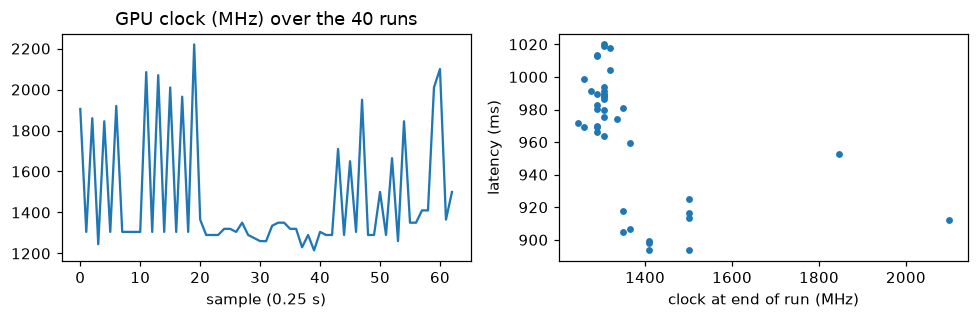

In [9]:
rows = sampler.rows
clk = np.array([r["clock_mhz"] for r in rows]); tmp = np.array([r["temp_c"] for r in rows])
pw = np.array([r["power_w"] for r in rows])
print(f"clock  : {clk.min():.0f} - {clk.max():.0f} MHz (median {np.median(clk):.0f})")
print(f"temp   : {tmp.min():.0f} - {tmp.max():.0f} C")
print(f"power  : {pw.min():.1f} - {pw.max():.1f} W")
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(clk); ax[0].set_title("GPU clock (MHz) over the 40 runs"); ax[0].set_xlabel("sample (0.25 s)")
ax[1].scatter(clk_at, lat, s=12); ax[1].set_xlabel("clock at end of run (MHz)"); ax[1].set_ylabel("latency (ms)")
plt.tight_layout(); plt.show()

Xung nhịp thay đổi đáng kể ngay trong vài chục giây. Mối liên hệ giữa xung nhịp và độ trễ
thường bị che một phần, vì `nvidia-smi` chỉ lấy mẫu mỗi 0,25 giây còn một lần chạy dài
gần một giây — con số xung nhịp ghi kèm chỉ là ảnh chụp tại một thời điểm.

Trên máy để bàn hay máy chủ, người ta **khoá xung nhịp** (`nvidia-smi --lock-gpu-clocks`) để
loại bỏ nguồn nhiễu này. GPU laptop này không cho phép, nên dự án phải **ghi lại** xung
nhịp và nhiệt độ cùng mỗi phép đo (quy tắc 6), và dùng các thiết kế đo chịu được nhiễu
(mục 5).

## 5. Trôi theo thời gian, và vì sao phải xen kẽ các cấu hình

Trong một phiên đo 25 phút, máy nóng dần lên và có thể chậm dần. Nếu đo **hết** cấu hình A
rồi mới đo cấu hình B, thì B luôn chạy trên một cái máy nóng hơn — chênh lệch do máy nóng
sẽ bị tính nhầm cho B. Mô phỏng: hai cấu hình **nhanh như nhau**, máy chậm dần tuyến tính
10% trong phiên đo.

In [10]:
n_per, drift = 100, 0.10
true_ms = 900.0
def session(order):
    """order: list of config labels in run order; returns measured latency per label."""
    out = defaultdict(list)
    for i, cfg in enumerate(order):
        slow = 1 + drift * i / (len(order) - 1)             # machine heats up over the session
        out[cfg].append(true_ms * slow * math.exp(rng.normal(0, 0.05)))
    return out

seq = session(["A"] * n_per + ["B"] * n_per)
inter = session(list(rng.permutation(["A", "B"] * n_per)))
for name, res in [("sequential A...A B...B", seq), ("interleaved, shuffled ", inter)]:
    print(f"{name}: B / A = {np.median(res['B']) / np.median(res['A']):.3f}   (truth: 1.000)")

sequential A...A B...B: B / A = 1.051   (truth: 1.000)
interleaved, shuffled : B / A = 1.006   (truth: 1.000)


Đo tuần tự báo B chậm hơn khoảng 5% — một kết luận hoàn toàn do máy nóng lên. Xen kẽ và
xáo trộn thứ tự làm trôi ảnh hưởng đều lên cả hai, nên tỉ số về gần 1.

Đây là việc `build_plan` trong `bench/harness.py` làm (quy tắc 2 và 3): mỗi **vòng** gồm mọi
cặp (câu hỏi, cấu hình), thứ tự trong vòng được xáo trộn với seed cố định. Mỗi dòng dưới đây
là (cấu hình, số thứ tự câu hỏi, vòng):

In [11]:
from bench.harness import build_plan
plan = build_plan(["baseline", "edge768"], n_samples=3, rounds=2, seed=0)
for step in plan:
    print(step)

('edge768', 1, 0)
('baseline', 2, 0)
('baseline', 1, 0)
('baseline', 0, 0)
('edge768', 2, 0)
('edge768', 0, 0)
('edge768', 1, 1)
('baseline', 0, 1)
('baseline', 1, 1)
('edge768', 2, 1)
('baseline', 2, 1)
('edge768', 0, 1)


Harness còn kiểm tra trôi trực tiếp: cấu hình đối chứng (baseline) được đo ở mọi vòng, nên so
vòng đầu với vòng cuối **trên cùng câu hỏi** cho biết máy đã trôi bao nhiêu (quy tắc 6):

In [12]:
for f in ["gate2_confirm.json", "gate2_sweep.json", "gate5_nf4.json", "gate6_prompt.json"]:
    print(f"{f:<20} control drift {load(f)['control_drift_pct']:+.1f}%")

gate2_confirm.json   control drift -0.5%
gate2_sweep.json     control drift +0.5%
gate5_nf4.json       control drift +0.6%
gate6_prompt.json    control drift +0.5%


Các lần chạy chính đều trôi dưới 2–3% — nhỏ so với các hiệu ứng được báo cáo.

## 6. Khi nào được nói "nhanh hơn"

Quy tắc 5 của dự án phân biệt hai loại so sánh, vì chúng có độ bất định rất khác nhau.

**(a) So một lần đo với một lần đo** — ví dụ độ trễ trung vị trong Docker so với chạy trực tiếp,
hai con số từ hai lần chạy riêng. Nếu mỗi lần có nhiễu tương đối $\sigma_r$, hiệu của chúng có độ
lệch chuẩn $\sqrt 2\,\sigma_r$ (phương sai của hiệu hai biến độc lập là tổng hai phương sai). Ngưỡng
$3\sigma_r$ vì vậy nằm cách 0 khoảng $3/\sqrt 2 \approx 2{,}1$ lần độ lệch chuẩn của hiệu — theo xấp
xỉ chuẩn, nhiễu thuần tuý vượt ngưỡng theo một chiều cụ thể chỉ khoảng 2% số lần. Đây là quy tắc
"gấp ba lần nhiễu", dùng CV bền vững của cổng 0 làm $\sigma_r$.

**(b) Trung vị tăng tốc theo cặp trên nhiều câu hỏi** — mọi đòn bẩy của dự án. Ở đây mỗi câu hỏi
cho một tỉ số thời gian, và trung vị của hàng trăm tỉ số chính xác hơn một lần đo đơn lẻ rất nhiều.
Dùng ngưỡng của loại (a) cho loại (b) là quá khắt khe. Cách đúng là khoảng tin cậy bootstrap của
chính trung vị đó (notebook 00, mục 7): **nhanh hơn thật khi cận dưới của khoảng lớn hơn 1**.

In [13]:
from bench.metrics import bootstrap_ci
sweep = load("gate2_sweep.json")
per = defaultdict(dict)
for r in sweep["records"]:
    per[r["sample_id"]].setdefault(r["config"], []).append(r["generate_ms"])
print(f"(a) single-measurement threshold: 3 x robust CV = {3 * robust_cv(raw):.1f}%")
for cfg in ["edge1152(edge=1152)", "keep0.5:uniform(keep=0.5,uniform)", "edge768(edge=768)"]:
    ratios = [statistics.median(d["baseline"]) / statistics.median(d[cfg])
              for d in per.values() if "baseline" in d and cfg in d]
    lo, hi = bootstrap_ci(ratios, stat=statistics.median, n_boot=4000)
    print(f"(b) {cfg.split('(')[0]:<16} {statistics.median(ratios):.2f}x  95% CI [{lo:.2f}, {hi:.2f}]  "
          f"-> {'faster' if lo > 1 else 'not distinguishable'}; above the (a) threshold: "
          f"{100 * (statistics.median(ratios) - 1) > 3 * robust_cv(raw)}")

(a) single-measurement threshold: 3 x robust CV = 18.1%
(b) edge1152         1.21x  95% CI [1.19, 1.24]  -> faster; above the (a) threshold: True
(b) keep0.5:uniform  1.10x  95% CI [1.09, 1.11]  -> faster; above the (a) threshold: False


(b) edge768          1.91x  95% CI [1.84, 1.95]  -> faster; above the (a) threshold: True


Cắt token còn 50% chỉ nhanh hơn khoảng 10% — dưới ngưỡng của loại (a) — nhưng khoảng tin cậy của nó
nằm hẳn trên 1: tăng tốc đó có thật, chỉ nhỏ. Dự án từng áp ngưỡng loại (a) cho mọi đòn bẩy và gạt
những tăng tốc như vậy đi (notebook 01, lỗi 6).

**Ký hiệu mới**
- $\sigma_r$: nhiễu tương đối của một lần đo (như ở mục 3.1)

## 7. Profiler: thời gian nằm ở phép tính nào

Đồng hồ cho biết **tổng** thời gian. Muốn biết thời gian nằm ở **phép tính nào**, dùng
**profiler**: công cụ ghi lại mọi phép tính và mọi kernel GPU cùng thời gian của chúng.
`torch.profiler` ghi được cả hai phía: thời gian CPU của từng phép toán PyTorch, và thời
gian GPU của từng kernel.

In [14]:
from torch.profiler import profile, ProfilerActivity
with torch.no_grad():
    gen()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        gen(); torch.cuda.synchronize()
table = prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=8, max_name_column_width=45)
print("\n".join(line[:130] for line in table.splitlines()))

USDT:2026-09-25 21:29:06 63618:63618 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-25 21:29:07 63618:63618 SyncActivityProfilerHandler.cpp:46] profiler_stop


---------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------ 
                                         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA 
---------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------ 
ampere_bf16_s1688gemm_bf16_128x128_ldg8_re...         0.00%       0.000us         0.00%       0.000us       0.000us     301.075ms 
std::enable_if<!(false), void>::type inter...         0.00%       0.000us         0.00%       0.000us       0.000us     147.856ms 
ampere_bf16_s1688gemm_bf16_128x128_ldg8_f2...         0.00%       0.000us         0.00%       0.000us       0.000us     120.421ms 
void pytorch_flash::flash_fwd_kernel<Flash...         0.00%       0.000us         0.00%       0.000us       0.000us      55.528ms 
void at::native::elementwise_kernel<128, 4...         0.00%       0.000us         0

Bảng xếp các kernel theo tổng thời gian GPU. Phần lớn thời gian là các kernel nhân ma trận
(`gemm`, `matmul`) và attention (`flash`) — đúng với những gì notebook 04 dự đoán: Transformer
dành gần hết thời gian cho các lớp tuyến tính. Notebook 05 dùng profiler để phát hiện một
điều mà đồng hồ không cho thấy: GPU **ngồi không** trong lúc chờ CPU.

Profiler cho biết thời gian theo **loại phép tính**; để biết thời gian theo **thành phần của
mô hình** (bộ mã hoá thị giác, connector, prefill, decode), dự án đo riêng từng thành phần
bằng CUDA event (`bench/breakdown.py`). Kết quả đó là đầu vào của mục cuối.

In [15]:
del model; torch.cuda.empty_cache()

## 8. Định luật Amdahl

Giả sử một phần của công việc chiếm tỉ lệ $p$ tổng thời gian, và ta làm phần đó nhanh hơn
$s$ lần. Thời gian mới (tính theo đơn vị thời gian cũ) là phần không đổi cộng phần đã tăng tốc:

$$T' = (1-p) + \frac{p}{s} \quad\Rightarrow\quad
\text{tăng tốc} = \frac{1}{(1-p) + p/s} \;\xrightarrow{\;s \to \infty\;}\; \frac{1}{1-p}$$

Kết luận của định luật: **dù phần được tối ưu nhanh vô hạn, tổng thể không bao giờ nhanh hơn
$1/(1-p)$**. Phần không tối ưu được trở thành trần.

**Ký hiệu mới**
- $p$: tỉ lệ thời gian của phần được tối ưu · $s$: mức tăng tốc của riêng phần đó

Áp vào bảng phân rã thời gian của dự án:

time shares: {'vision': '53.3%', 'connector': '0.3%', 'llm_prefill': '27.0%', 'decode': '19.1%'}
pruning after the encoder can only shrink the prefill: ceiling 1/(1-p) = 1.37x
keep0.5:uniform    tiles 13  input tokens   708 (prefill s = 1.75)  predicted 1.13x  measured 1.10x
keep0.25:uniform   tiles 13  input tokens   448 (prefill s = 2.77)  predicted 1.21x  measured 1.17x
keep0.077:uniform  tiles 13  input tokens   266 (prefill s = 4.67)  predicted 1.27x  measured 1.23x
edge768            tiles  5  input tokens   510 (prefill s = 2.43)  predicted 1.96x  measured 1.91x
nosplit            tiles  1  input tokens   144 (prefill s = 8.59)  predicted 3.75x  measured 3.29x


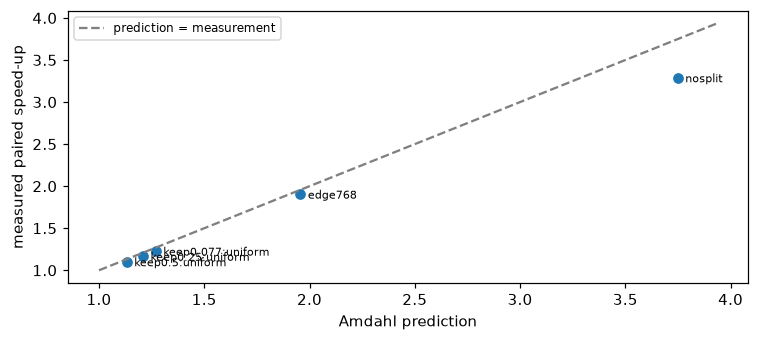

In [16]:
bd = load("breakdown.json")
share = {k: v / 100 for k, v in bd["share_pct"].items()}
print("time shares:", {k: f"{100 * v:.1f}%" for k, v in share.items()})

def amdahl(p, s):
    return 1 / ((1 - p) + p / s)

p_prefill = share["llm_prefill"]
print(f"pruning after the encoder can only shrink the prefill: ceiling 1/(1-p) = {1 / (1 - p_prefill):.2f}x")

# Generalised Amdahl: every part i with share p_i shrinks by its own factor s_i.
#   vision + connector shrink with the number of tiles, the prefill with the number of input tokens.
def predicted(tiles, tokens, base_tiles=13, base_tokens=None):
    p_vis = share["vision"] + share["connector"]
    rest = 1 - p_vis - p_prefill
    return 1 / (rest + p_vis * tiles / base_tiles + p_prefill * tokens / base_tokens)

tokens = {cfg: statistics.median(r["input_tokens"] for r in sweep["records"] if r["config"] == cfg)
          for cfg in sweep["configs"]}
tiles = {"baseline": 13, "edge768(edge=768)": 5, "nosplit(nosplit)": 1}
base_tok = tokens["baseline"]
rows = []
for cfg in ["keep0.5:uniform(keep=0.5,uniform)", "keep0.25:uniform(keep=0.25,uniform)",
            "keep0.077:uniform(keep=0.077,uniform)", "edge768(edge=768)", "nosplit(nosplit)"]:
    pred = predicted(tiles.get(cfg, 13), tokens[cfg], base_tokens=base_tok)
    meas = sweep["paired_speedup_vs_baseline"][cfg]["median_speedup"]
    rows.append((cfg.split("(")[0], tiles.get(cfg, 13), tokens[cfg], pred, meas))
    print(f"{cfg.split('(')[0]:<18} tiles {tiles.get(cfg, 13):>2}  input tokens {tokens[cfg]:>5.0f} "
          f"(prefill s = {base_tok / tokens[cfg]:.2f})  predicted {pred:.2f}x  measured {meas:.2f}x")

plt.scatter([r[3] for r in rows], [r[4] for r in rows])
for r in rows:
    plt.annotate(r[0], (r[3], r[4]), textcoords="offset points", xytext=(5, -3), fontsize=7)
lim = [1, max(max(r[3], r[4]) for r in rows) * 1.05]
plt.plot(lim, lim, "--", c="gray", label="prediction = measurement")
plt.xlabel("Amdahl prediction"); plt.ylabel("measured paired speed-up"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

Đọc biểu đồ:

- **Cắt token ảnh sau khi mã hoá** chỉ làm nhỏ prefill của mô hình ngôn ngữ — chưa tới một
  phần ba thời gian, nên trần của nó thấp dù cắt sạch mọi token.
- **Hệ số $s$ phải lấy từ dữ liệu, không đoán.** "Giữ 50% token" không làm prefill nhanh gấp 2: khoảng
  190 token chữ vẫn còn nguyên, nên số token đầu vào chỉ giảm từ khoảng 1.240 xuống khoảng 710. Với
  $s$ tính từ số token thật, dự đoán nằm sát số đo ở mọi cấu hình cắt token.
- **Giảm số ô ảnh** làm nhỏ cả bộ mã hoá (theo số ô) lẫn prefill (theo số token) — hơn 80% thời gian.
  Dự đoán cho cạnh 768 sát số đo. Với "một ô", số đo thấp hơn dự đoán: một ô đơn lẻ dùng GPU kém
  hiệu quả hơn một lô 13 ô (notebook 03, mục 6), nên bộ mã hoá không nhanh lên đủ 13 lần.

(Mô hình giả định thời gian mỗi phần tỉ lệ thuận với số ô hoặc số token — hợp lý với các pha
compute-bound theo notebook 04 — và pha sinh câu trả lời không đổi.)

**Định luật Amdahl tổng quát** — khi nhiều phần cùng tăng tốc, mỗi phần theo hệ số riêng:

$$\text{tăng tốc} = \frac{1}{\big(1 - \sum_i p_i\big) + \sum_i p_i / s_i}$$

**Ký hiệu mới**
- $p_i, s_i$: tỉ lệ thời gian và hệ số tăng tốc của phần thứ $i$

Bài học tổng quát, áp dụng cho mọi bài toán tối ưu: **đo xem thời gian nằm ở đâu trước, rồi
mới chọn chỗ tối ưu.** Kỹ thuật được bàn nhiều nhất (cắt token) nhắm vào phần không đủ lớn.

## Tóm tắt: sáu quy tắc đo của dự án

| # | Quy tắc | Bẫy mà nó chặn | Mục |
|---|---|---|---|
| 1 | Vùng bấm giờ bao trọn đường đi thật, ở mọi cấu hình | so hai đường đo khác phạm vi (notebook 01, lỗi 1) | 1 |
| 2 | Các vòng là bản lặp trên cùng tập mẫu | lẫn độ khó của mẫu với nhiễu | 3.1, 5 |
| 3 | Xen kẽ và xáo trộn thứ tự cấu hình, có seed | trôi theo thời gian | 5 |
| 4 | Báo trung vị và IQR | giá trị ngoại lai | 3 |
| 5 | Tăng tốc theo cặp: khoảng tin cậy loại trừ 1; một lần đo so một lần đo: vượt 3 lần nhiễu bền vững | kết luận vội, hoặc gạt bỏ oan | 6 |
| 6 | Ghi đại lượng bất biến và trạng thái máy; kiểm tra toàn vẹn (GPU dùng chung, đột biến) | đo nhầm thứ khác (notebook 01, lỗi 4 và 9); xung nhịp | 4 |